### xgb classifier

In this notebook, we attempt to predict nomination-worthy novels using XGBoost.

In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [2]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler, bool_to_integer
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(bool_to_integer, feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

We shall use **walk-forward nested time series cross-validation**.

In [4]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)


In [25]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

import xgboost as xgb

model =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgboost', xgb.XGBClassifier(
    eval_metric="ndcg",

    # determined through some hyperparameter iterations.
    max_depth=5,                       
    learning_rate=0.05,
    n_estimators=300,                  
    colsample_bytree=0.7,              
    subsample=0.9
))
])

In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, ndcg_score, recall_score, average_precision_score

cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    model.fit(
                book_train[features],
                book_train['target']            )
    
    ypred = model.predict(book_val[features])
    book_val['predicted'] = ypred

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'precision': precision, 
    'recall': recall
    })

# axes[0].set_ylabel('predicted score')
# axes[0].legend()
# plt.tight_layout()
# plt.show()


In [27]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.46712975085261277
STD of f1 score across folds:  0.08686977142536285


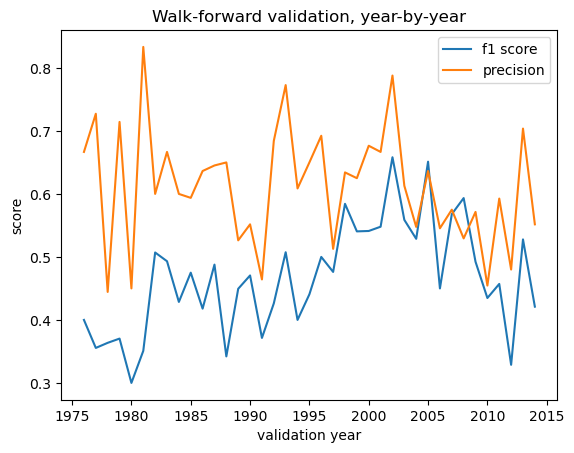

In [28]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')

plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

In [29]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importances = model.named_steps['xgboost'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
3      numerical_scaling__years_since_last_nomination    0.190893
0          numerical_scaling__Total_Awards_Previously    0.068982
81         nominee_similarity__past_winner_similarity    0.041520
80                 tag_similarity__cohort_similiarity    0.029048
19              onehot__first_publisher_bantamspectra    0.025994
4   numerical_scaling__publisher_historical_nomina...    0.025990
32                   onehot__first_publisher_gollancz    0.025312
79               onehot__month_of_publication_Unknown    0.025150
2                 numerical_scaling__author_num_books    0.024105
1        numerical_scaling__Author_Age_at_Publication    0.023790
63                        onehot__first_publisher_tor    0.023318
45                      onehot__first_publisher_orbit    0.021141
48                onehot__first_publisher_pocketbooks    0.020596
6                             bool_to_int__new_author    0.018053
29        

It is not clear that this is better than the XGBRanker, but it seems worth testing.

In [30]:
import joblib

export_path = 'trained_models/'

joblib.dump(model, export_path + "xgbclassifier_model.pkl") 

['trained_models/xgbclassifier_model.pkl']